# 1D Euler Equations: Finite Volume + WENO / TVD Schemes

This notebook solves the 1D compressible Euler equations using:
- First-order (Lax-Friedrichs)
- Minmod (2nd order TVD)
- WENO5 (high-order)

Test case: Sod Shock Tube

## Governing Equations (1D Euler)

The conservative form of the Euler equations:

$$
\frac{\partial \mathbf{Q}}{\partial t} + \frac{\partial \mathbf{F}(\mathbf{Q})}{\partial x} = 0
$$

where

$$
\mathbf{Q} =
\begin{bmatrix}
\rho \\
\rho u \\
E
\end{bmatrix}
,\quad
\mathbf{F} =
\begin{bmatrix}
\rho u \\
\rho u^2 + p \\
u(E + p)
\end{bmatrix}
$$

Equation of state:

$$
p = (\gamma - 1)\left(E - \frac{1}{2}\rho u^2\right)
$$

## Finite Volume Formulation

Integrating over a control volume:

$$
\frac{d}{dt} \mathbf{Q}_i =
- \frac{1}{\Delta x}
\left( \mathbf{F}_{i+\frac{1}{2}} - \mathbf{F}_{i-\frac{1}{2}} \right)
$$

Key idea:
- Compute **numerical fluxes at interfaces**
- Requires **left and right reconstructed states**

## Numerical Flux (Rusanov / Local Lax-Friedrichs)

$$
\mathbf{F}_{i+\frac{1}{2}} =
\frac{1}{2}
\left( \mathbf{F}_L + \mathbf{F}_R \right)
-
\frac{1}{2}
\alpha
\left( \mathbf{Q}_R - \mathbf{Q}_L \right)
$$

where

$$
\alpha = \max(|u| + c)
$$

and

$$
c = \sqrt{\gamma \frac{p}{\rho}}
$$

## Time Integration (TVD RK3)

Step 1:

$$
\mathbf{Q}^{(1)} = \mathbf{Q}^n + \Delta t \, L(\mathbf{Q}^n)
$$

Step 2:

$$
\mathbf{Q}^{(2)} =
\frac{3}{4}\mathbf{Q}^n +
\frac{1}{4}
\left(
\mathbf{Q}^{(1)} + \Delta t \, L(\mathbf{Q}^{(1)})
\right)
$$

Step 3:

$$
\mathbf{Q}^{n+1} =
\frac{1}{3}\mathbf{Q}^n +
\frac{2}{3}
\left(
\mathbf{Q}^{(2)} + \Delta t \, L(\mathbf{Q}^{(2)})
\right)
$$

## Time Step (CFL Condition)

$$
\Delta t =
\text{CFL} \cdot
\frac{\Delta x}{\max(|u| + c)}
$$

## First Order Reconstruction

No reconstruction:

$$
\mathbf{Q}_{i+\frac{1}{2}}^L = \mathbf{Q}_i
\quad
\mathbf{Q}_{i+\frac{1}{2}}^R = \mathbf{Q}_{i+1}
$$

## Minmod Limiter

Slope:

$$
\text{minmod}(a,b) =
\begin{cases}
\text{sign}(a)\min(|a|,|b|), & ab > 0 \\
0, & \text{otherwise}
\end{cases}
$$

Reconstruction:

$$
\mathbf{Q}_L =
\mathbf{Q}_i + \frac{1}{2} \, \text{minmod}(\Delta^- \mathbf{Q}, \Delta^+ \mathbf{Q})
$$

$$
\mathbf{Q}_R =
\mathbf{Q}_{i+1} - \frac{1}{2} \, \text{minmod}(\Delta^+ \mathbf{Q}, \Delta^{++} \mathbf{Q})
$$

## WENO5 Reconstruction

Three candidate stencils:

$$
q_0 = \frac{1}{3}Q_{i-2} - \frac{7}{6}Q_{i-1} + \frac{11}{6}Q_i
$$

$$
q_1 = -\frac{1}{6}Q_{i-1} + \frac{5}{6}Q_i + \frac{1}{3}Q_{i+1}
$$

$$
q_2 = \frac{1}{3}Q_i + \frac{5}{6}Q_{i+1} - \frac{1}{6}Q_{i+2}
$$

Smoothness indicators:

$$
\beta_0 = \frac{13}{12}(Q_{i-2}-2Q_{i-1}+Q_i)^2 + \frac{1}{4}(Q_{i-2}-4Q_{i-1}+3Q_i)^2
$$

$$
\beta_1 = \frac{13}{12}(Q_{i-1}-2Q_i+Q_{i+1})^2 + \frac{1}{4}(Q_{i-1}-Q_{i+1})^2
$$

$$
\beta_2 = \frac{13}{12}(Q_i-2Q_{i+1}+Q_{i+2})^2 + \frac{1}{4}(3Q_i-4Q_{i+1}+Q_{i+2})^2
$$

Weights:

$$
\alpha_k = \frac{d_k}{(\epsilon + \beta_k)^2}
$$

$$
w_k = \frac{\alpha_k}{\sum \alpha_k}
$$

Final reconstruction:

$$
Q_{i+1/2} = \sum_{k=0}^{2} w_k q_k
$$

## Boundary Conditions

Ghost cells are used:

$$
Q_{-1} = Q_0, \quad Q_{-2} = Q_0
$$

$$
Q_{N+1} = Q_N, \quad Q_{N+2} = Q_N
$$

(Zero-gradient / Neumann BC)

## Summary of the Algorithm

1. Initialize conservative variables
2. Apply boundary conditions
3. Reconstruct left/right states (WENO / TVD)
4. Compute numerical flux (Rusanov)
5. Compute RHS
6. Advance using RK3
7. Repeat until final time

## Why Higher-Order Schemes Are More Accurate

In finite volume methods, the numerical flux at each interface is obtained by solving a local Riemann problem using:

- Left state: $u^-_{i+1/2}$
- Right state: $u^+_{i+1/2}$

The accuracy of the method depends on how well these interface states are approximated.

## First-Order Scheme (Piecewise Constant)

In a first-order scheme:

- Each cell is assumed constant
- Interface states are taken as:
  
  $$
  u^-_{i+1/2} = u_i, \quad u^+_{i+1/2} = u_{i+1}
  $$

This means:

- The discontinuity is spread across a full cell
- The jump is of order $\mathcal{O}(\Delta x)$
- Interface values are poor approximations of the true solution

As a result:

- The Riemann problem is solved with inaccurate inputs
- Strong numerical diffusion is introduced
- Shocks and contacts are smeared over many cells

## Higher-Order Scheme (Reconstruction)

In higher-order schemes:

- Each cell is reconstructed using neighboring information
- Interface states are obtained by extrapolation:

  $$
  u^-_{i+1/2} = \text{reconstruction from cell } i
  $$
  $$
  u^+_{i+1/2} = \text{reconstruction from cell } i+1
  $$

This leads to:

- Much more accurate interface values
- The discontinuity is localized within the cell (sub-cell resolution)
- Error in interface states scales like $\mathcal{O}(\Delta x^p)$

As a result:

- The Riemann problem is more accurate
- Fluxes are more accurate
- Numerical diffusion is reduced
- Shocks become thinner and contacts sharper

## Key Insight

Higher-order schemes do not change the Riemann solver.

They improve the inputs to the Riemann problem.

> Higher-order schemes are more accurate because they provide better approximations of $u^-$ and $u^+$ at interfaces.

## Why Higher-Order Does Not Give High Convergence for Shock Problems

High-order accuracy requires the solution to be smooth.

However, in compressible flows:

- Shocks are discontinuities
- The solution is not differentiable
- Taylor expansion assumptions break down

## Behavior Near Shocks

Near discontinuities:

- High-order reconstruction creates oscillations (Gibbs phenomenon)
- To prevent instability, schemes use:
  - limiters (TVD)
  - nonlinear weights (WENO)

These mechanisms:

- Suppress oscillations
- Automatically reduce the scheme to first-order locally

## Convergence Behavior

For smooth problems:

$$
\text{Error} \sim \mathcal{O}(\Delta x^p)
$$

For problems with shocks:

- Error is dominated by the discontinuity
- Scheme behaves like first-order near shocks

Therefore:

$$
\text{Global convergence rate} \approx \mathcal{O}(\Delta x)
$$

## Final Takeaway

- Higher-order schemes improve accuracy by providing better interface states $(u^-, u^+)$
- This leads to a more accurate Riemann problem and flux

However:

- Near shocks, all schemes reduce to first-order behavior
- Global convergence becomes first-order

Still:

- Higher-order schemes give sharper shocks
- Reduce numerical diffusion
- Improve overall solution quality

Running Exact Solution...
Running 1st Order (LF)...
Running 2nd Order (Minmod)...
Running WENO5...

  L1 Errors  (Sod's Shock Tube, N=500, t=0.17)
  Scheme                       Density   Velocity   Pressure  Int. Energy
-----------------------------------------------------------------
  1st Order (LF)              0.009776   0.014206   0.007485     0.037824
  2nd Order (Minmod)          0.002567   0.003608   0.001655     0.010919
  WENO5                       0.001355   0.002256   0.000980     0.005629

  Cost ( L1 Error/Time)  (Sod's Shock Tube, N=500, t=0.17)-THE ORDER IS REVERED IN FORTAN CODE-euler1d.f90
  Scheme                      Density     Velocity     Pressure       Energy
-------------------------------------------------------------------------------------
  1st Order (LF)               0.0846       0.1229       0.0648       0.3273
  2nd Order (Minmod)           0.0133       0.0186       0.0085       0.0564
  WENO5                        0.0033       0.0054       0.0024   

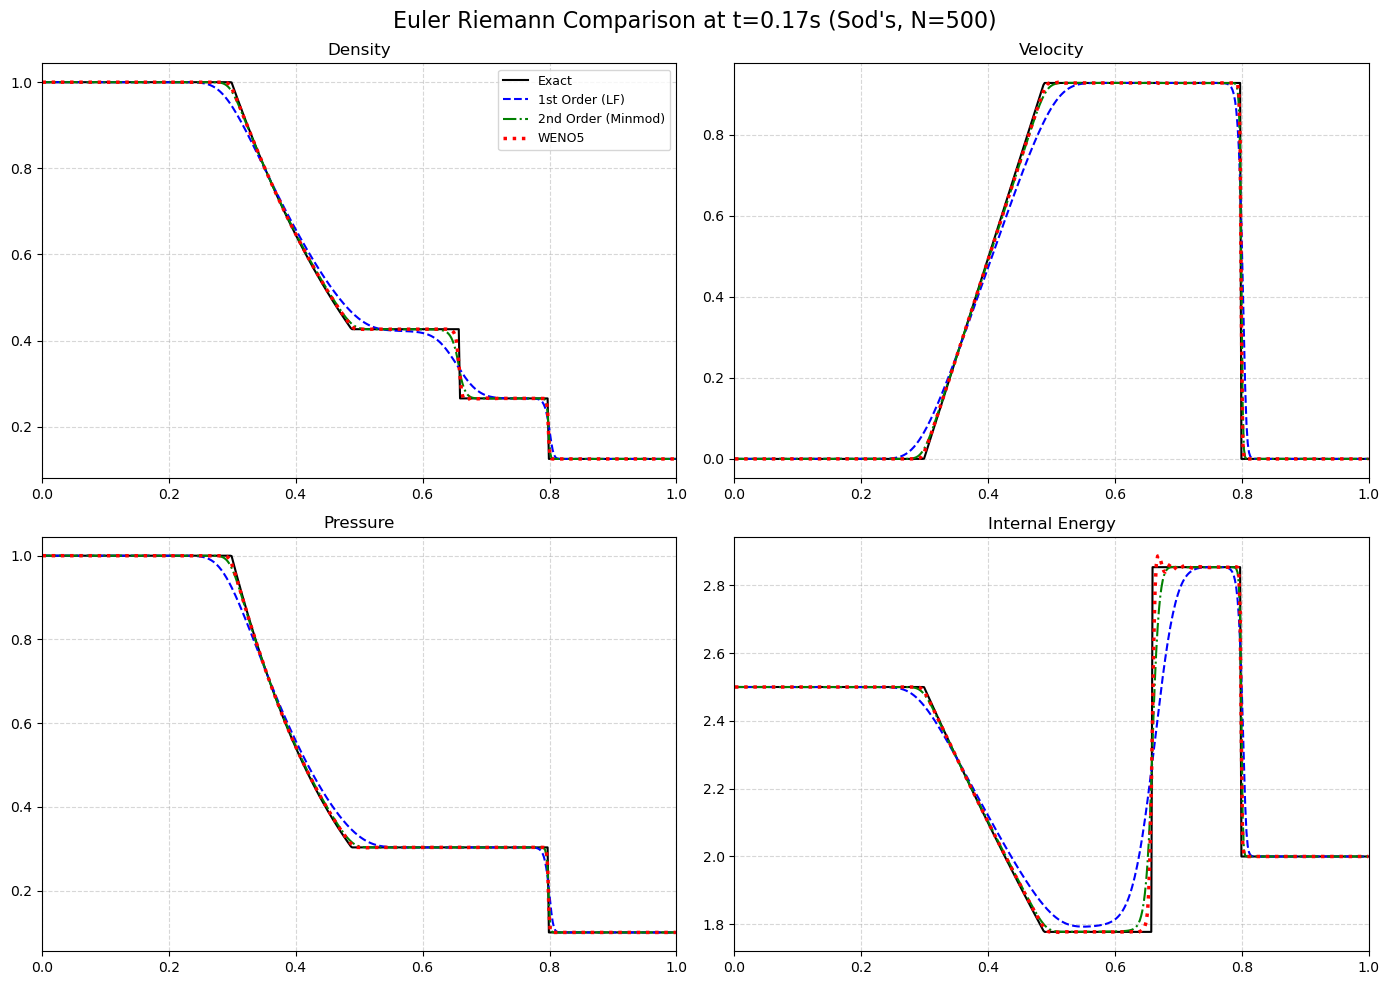

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import time

# =============================================================================
# Physics Constants & ICs
# =============================================================================
GAMMA = 1.4

def get_initial_conditions(case_id):
    cases = {
        1:  (1.0,   0.0,   1.0,    0.125, 0.0,   0.1,   0.17, 0.90), # Sod's
    }
    return cases.get(case_id, cases[1])

def init_domain(x, rhoL, uL, pL, rhoR, uR, pR):
    x_mid = (x[-1] + x[0]) / 2.0
    rho = np.where(x < x_mid, rhoL, rhoR)
    u   = np.where(x < x_mid, uL, uR)
    p   = np.where(x < x_mid, pL, pR)
    return rho, u, p

# =============================================================================
# Exact Riemann Solver
# =============================================================================
def exact_riemann_solver(x, t, rho1, u1, p1, rho4, u4, p4):
    if t == 0:
        x0 = 0.5
        rho_ex = np.where(x <= x0, rho1, rho4)
        u_ex = np.where(x <= x0, u1, u4)
        p_ex = np.where(x <= x0, p1, p4)
        return rho_ex, u_ex, p_ex, p_ex / ((GAMMA - 1) * rho_ex)
        
    alpha = (GAMMA + 1) / (GAMMA - 1)
    c1, c4 = np.sqrt(GAMMA * p1 / rho1), np.sqrt(GAMMA * p4 / rho4)
    PRL, CRL, MACHLEFT = p4 / p1, c4 / c1, (u1 - u4) / c1
    
    def f(P):
        term = 1 + MACHLEFT*(GAMMA-1)/2 - (GAMMA-1)*CRL*(P-1)/np.sqrt(2*GAMMA*(GAMMA-1 + (GAMMA+1)*P))
        if term < 0: return -1e10
        return (term**(2*GAMMA/(GAMMA-1))) / P - PRL

    try:
        p34 = root_scalar(f, bracket=[1e-6, 1e4], method='brentq').root
    except ValueError:
        p34 = 3.0 
        
    p3 = p34 * p4
    rho3 = rho4 * (1 + alpha * p34) / (alpha + p34)
    rho2 = rho1 * (p34 * p4 / p1)**(1 / GAMMA)
    u2 = u1 - u4 + (2/(GAMMA-1))*c1*(1 - (p34*p4/p1)**((GAMMA-1)/(2*GAMMA)))
    c2 = np.sqrt(GAMMA * p3 / rho2)
    
    x0 = 0.5
    spos   = x0 + t * c4 * np.sqrt((GAMMA-1)/(2*GAMMA) + (GAMMA+1)/(2*GAMMA)*p34) + t*u4
    conpos = x0 + u2 * t + t * u4
    pos1   = x0 + (u1 - c1) * t
    pos2   = x0 + (u2 + u4 - c2) * t

    rho_ex, u_ex, p_ex = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi <= pos1:
            p_ex[i], rho_ex[i], u_ex[i] = p1, rho1, u1
        elif xi <= pos2:
            p_ex[i] = p1 * (1 + (pos1 - xi) / (c1 * alpha * t))**(2 * GAMMA / (GAMMA - 1))
            rho_ex[i] = rho1 * (1 + (pos1 - xi) / (c1 * alpha * t))**(2 / (GAMMA - 1))
            u_ex[i] = u1 + (2 / (GAMMA + 1)) * (xi - pos1) / t
        elif xi <= conpos:
            p_ex[i], rho_ex[i], u_ex[i] = p3, rho2, u2 + u4
        elif xi <= spos:
            p_ex[i], rho_ex[i], u_ex[i] = p3, rho3, u2 + u4
        else:
            p_ex[i], rho_ex[i], u_ex[i] = p4, rho4, u4
            
    return rho_ex, u_ex, p_ex, p_ex / ((GAMMA - 1) * rho_ex)

# =============================================================================
# Reconstruction Schemes
# =============================================================================
def weno5_reconstruct(v):
    eps = 1e-6
    # Left-biased
    v_m2, v_m1, v_0, v_p1, v_p2 = v[:, :-5], v[:, 1:-4], v[:, 2:-3], v[:, 3:-2], v[:, 4:-1]
    b0 = 13/12 * (v_m2 - 2*v_m1 + v_0)**2 + 1/4 * (v_m2 - 4*v_m1 + 3*v_0)**2
    b1 = 13/12 * (v_m1 - 2*v_0 + v_p1)**2 + 1/4 * (v_m1 - v_p1)**2
    b2 = 13/12 * (v_0 - 2*v_p1 + v_p2)**2 + 1/4 * (3*v_0 - 4*v_p1 + v_p2)**2
    a0, a1, a2 = 0.1 / (eps + b0)**2, 0.6 / (eps + b1)**2, 0.3 / (eps + b2)**2
    w0, w1, w2 = a0/(a0+a1+a2), a1/(a0+a1+a2), a2/(a0+a1+a2)
    qL = w0 * (1/3 * v_m2 - 7/6 * v_m1 + 11/6 * v_0) + w1 * (-1/6 * v_m1 + 5/6 * v_0 + 1/3 * v_p1) + w2 * (1/3 * v_0 + 5/6 * v_p1 - 1/6 * v_p2)
    
    # Right-biased
    v_m2, v_m1, v_0, v_p1, v_p2 = v[:, 5:], v[:, 4:-1], v[:, 3:-2], v[:, 2:-3], v[:, 1:-4]
    b0 = 13/12 * (v_m2 - 2*v_m1 + v_0)**2 + 1/4 * (v_m2 - 4*v_m1 + 3*v_0)**2
    b1 = 13/12 * (v_m1 - 2*v_0 + v_p1)**2 + 1/4 * (v_m1 - v_p1)**2
    b2 = 13/12 * (v_0 - 2*v_p1 + v_p2)**2 + 1/4 * (3*v_0 - 4*v_p1 + v_p2)**2
    a0, a1, a2 = 0.1 / (eps + b0)**2, 0.6 / (eps + b1)**2, 0.3 / (eps + b2)**2
    w0, w1, w2 = a0/(a0+a1+a2), a1/(a0+a1+a2), a2/(a0+a1+a2)
    qR = w0 * (1/3 * v_m2 - 7/6 * v_m1 + 11/6 * v_0) + w1 * (-1/6 * v_m1 + 5/6 * v_0 + 1/3 * v_p1) + w2 * (1/3 * v_0 + 5/6 * v_p1 - 1/6 * v_p2)
    
    return qL, qR

def superbee_reconstruct(Q):
    Q_im1 = Q[:, 1:-4]
    Q_i   = Q[:, 2:-3]
    Q_ip1 = Q[:, 3:-2]
    Q_ip2 = Q[:, 4:-1]
    
    dq_i   = Q_ip1 - Q_i       
    dq_im1 = Q_i - Q_im1       
    dq_ip1 = Q_ip2 - Q_ip1     
    
    dq_i_safe = np.where(np.abs(dq_i) < 1e-12, 1e-12 * np.sign(dq_i + 1e-14), dq_i)
    r_L = dq_im1 / dq_i_safe   
    
    phi_L = np.maximum(0.0, np.maximum(np.minimum(2.0 * r_L, 1.0), np.minimum(r_L, 2.0)))
    qL = Q_i + 0.5 * phi_L * dq_i
    
    dq_ip1_safe = np.where(np.abs(dq_ip1) < 1e-12, 1e-12 * np.sign(dq_ip1 + 1e-14), dq_ip1)
    r_R = dq_i / dq_ip1_safe   
    
    phi_R = np.maximum(0.0, np.maximum(np.minimum(2.0 * r_R, 1.0), np.minimum(r_R, 2.0)))
    qR = Q_ip1 - 0.5 * phi_R * dq_ip1  
    
    return qL, qR

def minmod(a, b):
    return np.where(
        (a * b) > 0,
        np.sign(a) * np.minimum(np.abs(a), np.abs(b)),
        0.0
    )

def minmod_reconstruct(Q):
    Q_im1 = Q[:, 1:-4]
    Q_i   = Q[:, 2:-3]
    Q_ip1 = Q[:, 3:-2]
    Q_ip2 = Q[:, 4:-1]

    dq_im1 = Q_i - Q_im1
    dq_i   = Q_ip1 - Q_i
    dq_ip1 = Q_ip2 - Q_ip1

    slope_L = minmod(dq_im1, dq_i)
    qL = Q_i + 0.5 * slope_L

    slope_R = minmod(dq_i, dq_ip1)
    qR = Q_ip1 - 0.5 * slope_R

    return qL, qR

def first_order_reconstruct(Q):
    return Q[:, 2:-3], Q[:, 3:-2]

# =============================================================================
# Core Solver Elements
# =============================================================================
def euler_flux(Q):
    rho = np.maximum(Q[0, :], 1e-7) 
    u = Q[1, :] / rho
    E = Q[2, :]
    p = np.maximum((GAMMA - 1) * (E - 0.5 * rho * u**2), 1e-7) 
    
    F = np.zeros_like(Q)
    F[0, :], F[1, :], F[2, :] = rho * u, rho * u**2 + p, u * (E + p)
    return F, u, np.sqrt(GAMMA * p / rho)

def compute_rhs(Q, dx, scheme):
    if scheme == 'WENO5':
        QL, QR = weno5_reconstruct(Q)
    elif scheme == 'minmod':
        QL, QR = minmod_reconstruct(Q)
    elif scheme == 'superbee':
        QL, QR = superbee_reconstruct(Q)
    elif scheme == 'FirstOrder':
        QL, QR = first_order_reconstruct(Q)
        
    FL, uL, cL = euler_flux(QL)
    FR, uR, cR = euler_flux(QR)
    
    alpha = np.maximum(np.abs(uL) + cL, np.abs(uR) + cR)
    F_interface = 0.5 * (FL + FR) - 0.5 * alpha * (QR - QL)
    
    rhs = np.zeros_like(Q)
    rhs[:, 3:-3] = -(F_interface[:, 1:] - F_interface[:, :-1]) / dx
    return rhs

def apply_bcs(Q):
    for i in range(3):
        Q[:, i], Q[:, -1-i] = Q[:, 3], Q[:, -4]
    return Q

# =============================================================================
# Simulation
# =============================================================================
def simulate_scheme(scheme, nx, case_id):
    start_time = time.time() # Start tracking execution time
    rhoL, uL, pL, rhoR, uR, pR, tEnd, cfl_target = get_initial_conditions(case_id)
    cfl_target = min(cfl_target, 0.4)
    
    dx = 1.0 / nx
    x_pad = np.linspace(-3*dx + dx/2, 1 + 3*dx - dx/2, nx + 6)
    
    rho0, u0, p0 = init_domain(x_pad, rhoL, uL, pL, rhoR, uR, pR)
    Q = apply_bcs(np.array([rho0, rho0 * u0, p0 / (GAMMA - 1) + 0.5 * rho0 * u0**2]))
    
    t = 0.0
    while t < tEnd:
        rho = np.maximum(Q[0, 3:-3], 1e-7)
        u = Q[1, 3:-3] / rho
        p = np.maximum((GAMMA - 1) * (Q[2, 3:-3] - 0.5 * rho * u**2), 1e-7)
        dt = cfl_target * dx / np.max(np.abs(u) + np.sqrt(GAMMA * p / rho))
        
        if t + dt > tEnd: dt = tEnd - t
            
        Q1 = apply_bcs(Q + dt * compute_rhs(Q, dx, scheme))
        Q2 = apply_bcs(0.75 * Q + 0.25 * (Q1 + dt * compute_rhs(Q1, dx, scheme)))
        Q  = apply_bcs(1/3 * Q + 2/3 * (Q2 + dt * compute_rhs(Q2, dx, scheme)))
        t += dt

    rho_f = Q[0, 3:-3]
    u_f = Q[1, 3:-3] / rho_f
    p_f = (GAMMA - 1) * (Q[2, 3:-3] - 0.5 * rho_f * u_f**2)
    
    exec_time = time.time() - start_time # Calculate total duration
    # Return a tuple where the first element is the array data, and the second is time
    return (rho_f, u_f, p_f, p_f / ((GAMMA - 1) * rho_f)), exec_time

# =============================================================================
# L1 Error
# =============================================================================
def compute_l1_error(numerical, exact, dx):
    return np.sum(np.abs(numerical - exact)) * dx

# =============================================================================
# Execution and Plotting
# =============================================================================
def run_comparison(case_id=1, nx=200):
    rhoL, uL, pL, rhoR, uR, pR, tEnd, _ = get_initial_conditions(case_id)
    dx = 1.0 / nx
    x_phys = np.linspace(dx/2, 1-dx/2, nx)
    
    print("Running Exact Solution...")
    rho_ex, u_ex, p_ex, e_ex = exact_riemann_solver(x_phys, tEnd, rhoL, uL, pL, rhoR, uR, pR)
    
    schemes = ['FirstOrder', 'minmod', 'WENO5']
    labels  = ['1st Order (LF)', '2nd Order (Minmod)', 'WENO5']
    styles  = ['--b', '-.g', ':r']
    widths  = [1.5, 1.5, 2.5]
    results = {}
    
    for scheme, label in zip(schemes, labels):
        print(f"Running {label}...")
        results[scheme] = simulate_scheme(scheme, nx, case_id)
    
    # --- L1 Errors ---
    print("\n" + "="*65)
    print(f"  L1 Errors  (Sod's Shock Tube, N={nx}, t={tEnd})")
    print("="*65)
    print(f"  {'Scheme':<25s} {'Density':>10s} {'Velocity':>10s} {'Pressure':>10s} {'Int. Energy':>12s}")
    print("-"*65)
    
    for scheme, label in zip(schemes, labels):
        # Correctly unpack the tuple (data, time)
        (rho_n, u_n, p_n, e_n), _ = results[scheme]
        err_rho = compute_l1_error(rho_n, rho_ex, dx)
        err_u   = compute_l1_error(u_n, u_ex, dx)
        err_p   = compute_l1_error(p_n, p_ex, dx)
        err_e   = compute_l1_error(e_n, e_ex, dx)
        print(f"  {label:<25s} {err_rho:10.6f} {err_u:10.6f} {err_p:10.6f} {err_e:12.6f}")
    print("="*65)

    # --- Efficiency: Time divided by L1 Error (Lower is better) ---
    print("\n" + "="*85)
    print(f"  Cost ( L1 Error/Time)  (Sod's Shock Tube, N={nx}, t={tEnd})-THE ORDER IS REVERED IN FORTAN CODE-euler1d.f90")
    print("="*85)
    print(f"  {'Scheme':<22s} {'Density':>12s} {'Velocity':>12s} {'Pressure':>12s} {'Energy':>12s}")
    print("-" * 85)
    
    for scheme, label in zip(schemes, labels):
        (rho_n, u_n, p_n, e_n), exec_time = results[scheme]
        err_rho = compute_l1_error(rho_n, rho_ex, dx)
        err_u   = compute_l1_error(u_n, u_ex, dx)
        err_p   = compute_l1_error(p_n, p_ex, dx)
        err_e   = compute_l1_error(e_n, e_ex, dx)
        
        safe_err_rho = err_rho if err_rho > 0 else 1e-12
        safe_err_u   = err_u if err_u > 0 else 1e-12
        safe_err_p   = err_p if err_p > 0 else 1e-12
        safe_err_e   = err_e if err_e > 0 else 1e-12
        
        cost_rho = (exec_time / safe_err_rho)**-1 
        cost_u   = (exec_time / safe_err_u)**-1 
        cost_p   = (exec_time / safe_err_p)**-1
        cost_e   = (exec_time / safe_err_e)**-1 
        
        print(f"  {label:<22s} {cost_rho:12.4f} {cost_u:12.4f} {cost_p:12.4f} {cost_e:12.4f}")
    print("="*85)
    
    # --- Plotting ---
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Euler Riemann Comparison at t={tEnd}s (Sod's, N={nx})", fontsize=16)
    
    var_names = ['Density', 'Velocity', 'Pressure', 'Internal Energy']
    var_exact = [rho_ex, u_ex, p_ex, e_ex]
    
    for idx, (ax, vname, v_ex) in enumerate(zip(axs.flat, var_names, var_exact)):
        ax.plot(x_phys, v_ex, '-k', linewidth=1.5, label='Exact')
        for scheme, label, style, lw in zip(schemes, labels, styles, widths):
            # Extract just the data part (index 0) from results[scheme] for plotting
            data = results[scheme][0]
            ax.plot(x_phys, data[idx], style, linewidth=lw, label=label)
        ax.set_title(vname)
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle='--', alpha=0.5)
        if idx == 0:
            ax.legend(fontsize=9)
            
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_comparison(case_id=1, nx=500)